In [ ]:
# ==================================================
# CELL 1: DEPENDENCIES
# ==================================================
# Shared setup cell.
# Needed for the full pipeline:
# - transformers / torch for LLM extraction + critic
# - keybert / sentence-transformers for parallel extraction
# - pandas / tqdm for processing and outputs
# ==================================================

%pip install -q transformers accelerate torch tqdm pandas huggingface_hub safetensors bitsandbytes keybert sentence-transformers scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 52.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 5.0 MB/s eta 0:00:00


In [ ]:
# ==================================================
# CELL 2: IMPORTS
# ==================================================
# Shared infrastructure cell.
# Used across the whole notebook.
# Spencer-specific addition:
# - KeyBERT import for parallel extraction path
# ==================================================

import json
import gc
import logging
import os
import re
from typing import Any, Callable, Dict, List, Optional, Tuple

import pandas as pd
import torch
from IPython.display import display
from tqdm.auto import tqdm

from keybert import KeyBERT

logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")
logger = logging.getLogger("keyword_pipeline")

In [ ]:
# ==================================================
# CELL 3: CONFIG / MODEL IDS
# ==================================================
# Shared configuration cell.
#
# Spencer-relevant additions:
# - EDGE_CASE_WORD_THRESHOLD for short-description handling
# - KEYBERT_TOP_N for parallel extraction output size
# - MAX_NEW_TOKENS_TOPIC for topic generation in edge cases
#
# Critic merge additions:
# - PROCESS_START_INDEX / PROCESS_LIMIT for controlled runs
# - BATCH_SIZE / WRITE_BATCH_FILES for chunked outputs
# - INPUT_JSON_GLOB for loading multiple opportunity files
# ==================================================

try:
    from google.colab import userdata
    _hf = userdata.get("HF_TOKEN")
    os.environ["HF_TOKEN"] = _hf
except Exception:
    pass

os.environ["HF_TOKEN"] = ""

EXTRACTOR_MODEL_ID = os.environ.get("EXTRACTOR_MODEL_ID", "microsoft/phi-2")
CRITIC_MODEL_ID = os.environ.get("CRITIC_MODEL_ID", EXTRACTOR_MODEL_ID)
HF_TOKEN = os.environ.get("HF_TOKEN") or os.environ.get("HUGGING_FACE_HUB_TOKEN")

MAX_NEW_TOKENS_EXTRACTOR = int(os.environ.get("MAX_NEW_TOKENS_EXTRACTOR", "50"))
MAX_NEW_TOKENS_TOPIC = int(os.environ.get("MAX_NEW_TOKENS_TOPIC", "30"))
MAX_NEW_TOKENS_CRITIC = int(os.environ.get("MAX_NEW_TOKENS_CRITIC", "200"))

GENERATION_GREEDY = os.environ.get("GENERATION_GREEDY", "1") == "1"
JSON_PARSE_RETRIES = 2

EDGE_CASE_WORD_THRESHOLD = int(os.environ.get("EDGE_CASE_WORD_THRESHOLD", "25"))
KEYBERT_TOP_N = int(os.environ.get("KEYBERT_TOP_N", "8"))

INPUT_JSON_PATH = os.environ.get("INPUT_JSON_PATH", "opportunities_sample.json")
PROCESS_START_INDEX = int(os.environ.get("PROCESS_START_INDEX", "0"))
PROCESS_LIMIT = int(os.environ.get("PROCESS_LIMIT", "10"))

# NEW: Critic scoring thresholds to prevent over-pruning
MIN_CRITIC_SCORE_TO_KEEP = float(os.environ.get("MIN_CRITIC_SCORE_TO_KEEP", "0.15"))  # Lower threshold
MIN_KEYWORDS_PER_OPP = int(os.environ.get("MIN_KEYWORDS_PER_OPP", "3"))  # Ensure minimum keywords

# NEW: Output control
WRITE_BATCH_FILES = False  # Always false now - single output at end
OUTPUT_DIR = os.environ.get("OUTPUT_DIR", "/content/drive/MyDrive/keyword_outputs")

DEVICE = torch.device("cpu")
DTYPE = torch.float32


In [ ]:
# ==================================================
# CELL 4: PROMPT TEMPLATES
# ==================================================
# Spencer ownership:
# - redesigned extractor prompt
# - removed forced 5-12 keyword requirement
# - removed extractor-side rubric/scoring
# - added TOPIC_PROMPT for edge-case handling
#
# Downstream / shared:
# - critic prompt feeds refinement + scoring stage
#
# Critic merge note:
# - keep base extractor/topic prompts
# - use richer critic review schema for detailed outputs
# ==================================================

EXTRACTOR_PROMPT = """You are an expert at extracting meaningful research keywords from funding opportunity descriptions.

GOAL:
Identify the most important, domain-specific keywords that represent the core topics, methods, and objectives of the opportunity.

TASKS:
1. Identify the main research area(s)
2. Extract specific methods or techniques (if present)
3. Identify target populations, systems, or domains
4. Capture key problems or objectives described
5. Combine words into meaningful multi-word phrases where appropriate

GUIDELINES:
- Prefer 2–4 word phrases (e.g., "hydrological variability analysis")
- Avoid generic words (program, project, research, information, note)
- Avoid administrative/boilerplate terms (Federal Register, CFDA, funding notice)
- Each keyword must be meaningful on its own
- Avoid duplicates or overlapping phrases
- Only include terms explicitly supported by the text

FEW-SHOT EXAMPLES:

Example 1:
Input: "This project studies youth violence in schools and aims to develop prevention strategies."
Output:
{{"keywords": ["youth violence prevention", "school safety programs"]}}

Example 2:
Input: "Research on climate-driven hydrological variability using dendrochronology."
Output:
{{"keywords": ["hydrological variability", "climate impact modeling", "dendrochronological analysis"]}}

CONSTRAINTS:
- Return at most 6 keywords
- Do NOT include explanations
- Output MUST be valid JSON

OUTPUT FORMAT:
{{"keywords": ["...", "..."]}}

TEXT:
{input_text}
"""

TOPIC_PROMPT = """You are helping interpret a very short or sparse funding opportunity description.

Generate one short topic phrase that best captures the main subject of the text.

Rules:
- Output one short phrase only
- Keep it broad but faithful to the text
- Do not invent unsupported details
- Do not explain anything

Return ONLY valid JSON:

{{
  "topic": "..."
}}

TEXT:
{input_text}
"""
CRITIC_PROMPT = """You are an expert reviewer of keyword extraction results.

GOAL:
Select and refine high-quality keywords while preserving multiple distinct research concepts.

TASKS:
1. Remove generic or irrelevant keywords
2. Lightly refine keywords into clean phrases (without over-generalizing)
3. Score each keyword using the weighted system below
4. Keep multiple useful, distinct keywords (do not collapse to only one)

WEIGHTED SCORING:

Evaluate each keyword on:

- Specificity (0–1): how precise and domain-specific it is
- Relevance (0–1): how well it matches the text
- Phrase Quality (0–1): whether it is a meaningful multi-word phrase
- Uniqueness (0–1): whether it avoids redundancy

Compute:

final_score =
  0.4 * specificity +
  0.3 * relevance +
  0.2 * phrase_quality +
  0.1 * uniqueness

GUIDELINES:

Keep keywords that are:
- specific and descriptive
- directly grounded in the text
- meaningful phrases (prefer 2–4 words)
- representing different aspects of the project (methods, topics, applications)

Remove keywords that are:
- generic ("program", "project", "note")
- vague ("related issues", "data", "process")
- administrative ("Federal Register", "CFDA")

IMPORTANT RULES:
- Do NOT over-merge keywords into one concept
- Do NOT collapse multiple valid concepts into a single keyword
- Preserve multiple distinct focal points from the text
- Prefer slightly specific phrases over overly broad ones
- Avoid duplicates or very similar terms, but keep coverage

FEW-SHOT EXAMPLES:

Example 1:
Input:
["youth", "violence", "related issues", "note"]

Output:
{{
  "keywords": [
    {{
      "term": "youth violence prevention",
      "original_score": 0.0,
      "analysis": "Specific and meaningful phrase",
      "updated_score": 0.88,
      "keep": true
    }},
    {{
      "term": "school safety programs",
      "original_score": 0.0,
      "analysis": "Relevant supporting concept",
      "updated_score": 0.82,
      "keep": true
    }},
    {{
      "term": "note",
      "original_score": 0.0,
      "analysis": "Generic and not useful",
      "updated_score": 0.05,
      "keep": false
    }}
  ]
}}

Example 2:
Input:
["dendrochronological", "reconstructions", "hydrological variability"]

Output:
{{
  "keywords": [
    {{
      "term": "dendrochronological reconstruction",
      "original_score": 0.0,
      "analysis": "Specific method from text",
      "updated_score": 0.9,
      "keep": true
    }},
    {{
      "term": "hydrological variability analysis",
      "original_score": 0.0,
      "analysis": "Distinct research focus",
      "updated_score": 0.85,
      "keep": true
    }}
  ]
}}

CONSTRAINTS:
- Output MUST be valid JSON
- Do NOT include explanations outside JSON
- Keep output concise
- Keep at least 2–4 high-quality keywords when possible
- Do NOT add more than 2 new keywords

OUTPUT FORMAT:
{{
  "keywords": [
    {{
      "term": "...",
      "original_score": 0.0,
      "analysis": "...",
      "updated_score": 0.0,
      "keep": true
    }}
  ]
}}

TEXT:
{input_text}

INITIAL KEYWORDS:
{keywords_json}
"""

# CRITIC_PROMPT = """You are an expert reviewer of keyword extraction results.

# GOAL:
# Select and refine the best keywords using a weighted scoring system.

# TASKS:
# 1. Remove generic or irrelevant keywords
# 2. Merge or improve keywords into meaningful phrases
# 3. Score each keyword using the weighted system below
# 4. Keep only useful, high-quality keywords

# WEIGHTED SCORING:

# Evaluate each keyword on:

# - Specificity (0–1): how precise and domain-specific it is
# - Relevance (0–1): how well it matches the text
# - Phrase Quality (0–1): whether it is a meaningful multi-word phrase
# - Uniqueness (0–1): whether it avoids redundancy

# Compute:

# final_score =
#   0.4 * specificity +
#   0.3 * relevance +
#   0.2 * phrase_quality +
#   0.1 * uniqueness

# GUIDELINES:

# Keep keywords that are:
# - specific and descriptive
# - useful for matching research expertise
# - meaningful phrases (prefer 2–4 words)

# Remove keywords that are:
# - generic ("program", "project", "note")
# - vague ("related issues", "data", "process")
# - administrative ("Federal Register", "CFDA")

# RULES:
# - Prefer phrases over single words
# - Merge words when possible (e.g., "youth" + "violence" → "youth violence prevention")
# - Avoid duplicates or very similar terms

# FEW-SHOT EXAMPLES:

# Example 1:
# Input:
# ["youth", "violence", "related issues", "note"]

# Output:
# {{
#   "keywords": [
#     {{
#       "term": "youth violence prevention",
#       "original_score": 0.0,
#       "analysis": "Specific and meaningful phrase",
#       "updated_score": 0.88,
#       "keep": true
#     }},
#     {{
#       "term": "note",
#       "original_score": 0.0,
#       "analysis": "Generic and not useful",
#       "updated_score": 0.05,
#       "keep": false
#     }}
#   ]
# }}

# Example 2:
# Input:
# ["dendrochronological", "reconstructions", "hydrological variability"]

# Output:
# {{
#   "keywords": [
#     {{
#       "term": "dendrochronological reconstruction",
#       "original_score": 0.0,
#       "analysis": "Merged into a specific phrase",
#       "updated_score": 0.9,
#       "keep": true
#     }},
#     {{
#       "term": "hydrological variability analysis",
#       "original_score": 0.0,
#       "analysis": "Relevant and domain-specific",
#       "updated_score": 0.85,
#       "keep": true
#     }}
#   ]
# }}

# CONSTRAINTS:
# - Output MUST be valid JSON
# - Do NOT include explanations outside JSON
# - Keep output concise
# - Do NOT add more than 2 new keywords

# OUTPUT FORMAT:
# {{
#   "keywords": [
#     {{
#       "term": "...",
#       "original_score": 0.0,
#       "analysis": "...",
#       "updated_score": 0.0,
#       "keep": true
#     }}
#   ]
# }}

# TEXT:
# {input_text}

# INITIAL KEYWORDS:
# {keywords_json}
# """

In [ ]:
# ==================================================
# CELL 5: PARSING LAYER
# ==================================================
# Shared system component:
# - general JSON extraction / cleanup / fallback parsing
# - supports robustness against malformed LLM output
#
# Spencer additions:
# - parse_keyword_list_payload: supports new extractor output format
# - parse_topic_payload: supports edge-case topic generation
# - normalize_phrase / dedupe_preserve_order:
#   supports merging LLM + KeyBERT outputs
#
# Critic merge additions:
# - parse_critic_keywords_payload: supports detailed critic schema
# - regex fallback preserves keep / updated_score when JSON is malformed
#
# Person 3 domain overlap:
# - general parsing reliability still belongs to JSON robustness work
# ==================================================

def _extract_json_object(text: str) -> str:
    text = text.strip()
    fence = re.search(r"```(?:json)?\s*([\s\S]*?)\s*```", text, re.IGNORECASE)
    if fence:
        text = fence.group(1).strip()
    start = text.find("{")
    if start == -1:
        raise ValueError("No JSON object found in model output")
    depth = 0
    in_str = False
    esc = False
    for i in range(start, len(text)):
        c = text[i]
        if in_str:
            if esc:
                esc = False
            elif c == "\\":
                esc = True
            elif c == '"':
                in_str = False
            continue
        if c == '"':
            in_str = True
            continue
        if c == "{":
            depth += 1
        elif c == "}":
            depth -= 1
            if depth == 0:
                return text[start : i + 1]
    raise ValueError("Unbalanced JSON braces in model output")


def _trim_code_hallucination_tail(raw: str) -> str:
    s = raw.strip()
    cut = len(s)
    for m in (
        '\n"""',
        '\nimport ',
        '\nfrom ',
        '\n# Solution',
        '\n```',
        '\n\nimport ',
    ):
        i = s.find(m)
        if i != -1:
            cut = min(cut, i)
    return s[:cut].strip()


# --- Spencer: used to normalize and merge parallel keyword outputs ---
def normalize_phrase(term: str) -> str:
    term = str(term).strip().lower()
    term = re.sub(r"\s+", " ", term)
    term = re.sub(r"[^\w\s\-\/]", "", term)
    return term.strip()


# --- Spencer: deduplicate LLM + KeyBERT candidates while preserving order ---
def dedupe_preserve_order(items: List[str]) -> List[str]:
    seen = set()
    out = []
    for item in items:
        norm = normalize_phrase(item)
        if not norm or norm in seen:
            continue
        seen.add(norm)
        out.append(item.strip())
    return out


# --- Spencer: parses extractor output from new plain keyword-list JSON format ---
def parse_keyword_list_payload(raw: str, min_keywords: int = 1) -> List[str]:
    raw = raw.replace("```python", "").replace("```", "").strip()

    # Fix truncated JSON
    if raw.count("{") > raw.count("}"):
        raw += "}"
    if raw.count("[") > raw.count("]"):
        raw += "]"

    raw = _trim_code_hallucination_tail(raw)

    try:
        blob = _extract_json_object(raw)
        data = json.loads(blob)
        kws = data.get("keywords", [])
        if not isinstance(kws, list):
            kws = []
        cleaned = [k.strip() for k in kws if isinstance(k, str) and k.strip()]
        cleaned = dedupe_preserve_order(cleaned)

        # If extractor gave nothing, return empty list instead of raising
        return cleaned

    except Exception:
        # FINAL FALLBACK: extract anything that looks like a keyword
        terms = re.findall(r'"([^"]+)"', raw)
        terms = [t.strip() for t in terms if t.strip()]
        return dedupe_preserve_order(terms)


# --- Spencer: parses edge-case topic output ---
def parse_topic_payload(raw: str) -> str:
    raw = _trim_code_hallucination_tail(raw)
    blob = _extract_json_object(raw)
    data = json.loads(blob)
    topic = str(data.get("topic", "")).strip()
    if not topic:
        raise ValueError("Missing topic")
    return topic


# --- Shared / critic-side parsing utilities ---
_KW_OBJECT_RE = re.compile(
    r'\{\s*"term"\s*:\s*("(?:\\.|[^"\\])*")\s*,\s*"score"\s*:\s*(-?\d+\.?\d*)\s*\}'
)


def _keywords_from_regex(raw: str) -> List[Dict[str, Any]]:
    out: List[Dict[str, Any]] = []
    for m in _KW_OBJECT_RE.finditer(raw):
        try:
            term_s = str(json.loads(m.group(1))).strip()
            score_f = float(m.group(2))
        except (json.JSONDecodeError, TypeError, ValueError):
            continue
        if term_s:
            out.append({"term": term_s, "score": score_f})
    return out


def _normalize_keyword_items(kws: Any) -> List[Dict[str, Any]]:
    cleaned: List[Dict[str, Any]] = []
    if not isinstance(kws, list):
        return cleaned
    for item in kws:
        if not isinstance(item, dict):
            continue
        term = item.get("term")
        score = item.get("score")
        if term is None or score is None:
            continue
        term_s = str(term).strip()
        if not term_s:
            continue
        try:
            score_f = float(score)
        except (TypeError, ValueError):
            continue
        cleaned.append({"term": term_s, "score": score_f})
    return cleaned


def _coerce_bool(value: Any, default: bool = True) -> bool:
    if isinstance(value, bool):
        return value
    if value is None:
        return default
    return str(value).strip().lower() in {"true", "1", "yes", "y"}


def _critic_keywords_from_regex(raw: str) -> List[Dict[str, Any]]:
    terms = re.findall(r'"term"\s*:\s*"([^"]+)"', raw)
    original_scores = re.findall(r'"original_score"\s*:\s*(-?\d+\.?\d*)', raw)
    updated_scores = re.findall(r'"updated_score"\s*:\s*(-?\d+\.?\d*)', raw)
    keep_flags = re.findall(r'"keep"\s*:\s*(true|false)', raw, flags=re.IGNORECASE)

    if not updated_scores:
        updated_scores = re.findall(r'"score"\s*:\s*(-?\d+\.?\d*)', raw)
    while len(original_scores) < len(terms):
        original_scores.append("0.0")
    while len(updated_scores) < len(terms):
        updated_scores.append("0.0")
    while len(keep_flags) < len(terms):
        keep_flags.append("true")

    cleaned: List[Dict[str, Any]] = []
    for term, original_score, updated_score, keep_flag in zip(terms, original_scores, updated_scores, keep_flags):
        term_s = str(term).strip()
        if not term_s:
            continue
        try:
            original_score_f = float(original_score)
            updated_score_f = float(updated_score)
        except ValueError:
            continue
        keep_b = str(keep_flag).lower() == "true"
        cleaned.append({
            "term": term_s,
            "original_score": original_score_f,
            "analysis": "",
            "updated_score": updated_score_f,
            "keep": keep_b,
            "score": updated_score_f,
        })
    return cleaned


def parse_scored_keywords_payload(raw: str, min_keywords: int = 1) -> List[Dict[str, Any]]:
    raw = _trim_code_hallucination_tail(raw)
    cleaned: List[Dict[str, Any]] = []
    try:
        blob = _extract_json_object(raw)
        data = json.loads(blob)
        if isinstance(data, dict) and "keywords" in data:
            cleaned = _normalize_keyword_items(data["keywords"])
    except (ValueError, json.JSONDecodeError):
        pass
    if len(cleaned) < min_keywords:
        rx = _keywords_from_regex(raw)
        if len(rx) >= len(cleaned):
            cleaned = rx
    if len(cleaned) < min_keywords:
        raise ValueError(f"Expected at least {min_keywords} scored keywords after parse, got {len(cleaned)}")
    return cleaned


def parse_critic_keywords_payload(raw: str, min_keywords: int = 1) -> List[Dict[str, Any]]:
    raw = raw.replace("```python", "").replace("```", "").strip()
    # Fix truncated JSON
    if raw.count("{") > raw.count("}"):
        raw += "}"
    if raw.count("[") > raw.count("]"):
        raw += "]"
    raw = _trim_code_hallucination_tail(raw)
    cleaned: List[Dict[str, Any]] = []
    try:
        blob = _extract_json_object(raw)
        data = json.loads(blob)
        kws = data.get("keywords", []) if isinstance(data, dict) else []
        if not isinstance(kws, list):
            raise ValueError("keywords is not a list")
        for item in kws:
            if not isinstance(item, dict):
                continue
            term = str(item.get("term", "")).strip()
            if not term:
                continue
            original_score = item.get("original_score", item.get("score", 0.0))
            updated_score = item.get("updated_score", item.get("score", original_score))
            try:
                original_score_f = float(original_score)
                updated_score_f = float(updated_score)
            except (TypeError, ValueError):
                continue
            cleaned.append({
                "term": term,
                "original_score": original_score_f,
                "analysis": str(item.get("analysis", "")).strip(),
                "updated_score": updated_score_f,
                "keep": _coerce_bool(item.get("keep", True), default=True),
                "score": updated_score_f,
            })
    except (ValueError, json.JSONDecodeError, TypeError):
        pass

    if len(cleaned) < min_keywords:
      rx = _critic_keywords_from_regex(raw)
      if len(rx) >= len(cleaned):
        cleaned = rx

    if len(cleaned) < min_keywords:
      # FALLBACK: extract terms even if JSON is broken
      terms = re.findall(r'"term"\s*:\s*"([^"]+)"', raw)

      if not terms:
        # fallback for single quotes
        terms = re.findall(r"'term'\s*:\s*'([^']+)'", raw)

      if terms:
        return [
            {
                "term": t,
                "original_score": 0.0,
                "analysis": "",
                "updated_score": 0.5,
                "keep": True,
                "score": 0.5,
            }
            for t in terms
        ]

      raise ValueError(
        f"Expected at least {min_keywords} critic keywords after parse, got {len(cleaned)}"
      )

    return cleaned


In [ ]:
# ==================================================
# CELL 6: SCORE NORMALIZATION
# ==================================================
# Downstream / shared utility.
# Used after critic scoring so final keyword scores are normalized to 0-1
# ==================================================

def normalize_scores_minmax(keywords: List[Dict[str, Any]], eps: float = 1e-8) -> List[Dict[str, Any]]:
    if not keywords:
        return []
    scores = [float(k["score"]) for k in keywords]
    lo, hi = min(scores), max(scores)
    denom = (hi - lo) + eps
    out = []
    for k in keywords:
        s = float(k["score"])
        norm = (s - lo) / denom
        norm = max(0.0, min(1.0, norm))
        out.append({"term": k["term"], "score": norm})
    return out

In [ ]:
# ==================================================
# CELL 7: MODEL LOADING
# ==================================================
# Shared infrastructure:
# - loads extractor LLM
# - loads critic LLM
#
# Spencer addition:
# - KeyBERT backend initialization for parallel extraction
#
# IMPORTANT FIX:
# - kw_model must be initialized before keybert_extract_keywords is called
# ==================================================

from transformers import AutoConfig, AutoModelForCausalLM, AutoTokenizer


def _strip_training_quant_flags_from_config(cfg: Any) -> None:
    for name in (
        "load_in_8bit",
        "load_in_4bit",
        "bnb_4bit_quant_type",
        "bnb_4bit_use_double_quant",
        "bnb_4bit_compute_dtype",
        "llm_int8_threshold",
        "llm_int8_skip_modules",
    ):
        if hasattr(cfg, name):
            try:
                delattr(cfg, name)
            except Exception:
                pass


def _load_causal_lm(model_id: str, token: Optional[str]) -> Tuple[AutoModelForCausalLM, AutoTokenizer]:
    tok_kwargs: Dict[str, Any] = {"trust_remote_code": True}
    auth = {"token": token} if token else {}

    tokenizer = AutoTokenizer.from_pretrained(model_id, **tok_kwargs, **auth)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    pad_id = tokenizer.pad_token_id

    config = AutoConfig.from_pretrained(model_id, trust_remote_code=True, **auth)
    _strip_training_quant_flags_from_config(config)
    if getattr(config, "pad_token_id", None) is None and pad_id is not None:
        setattr(config, "pad_token_id", pad_id)

    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        config=config,
        trust_remote_code=True,
        **auth,
    )
    model = model.to(DEVICE)
    model.eval()

    if getattr(model.config, "pad_token_id", None) is None and pad_id is not None:
        setattr(model.config, "pad_token_id", pad_id)

    gen_cfg = getattr(model, "generation_config", None)
    if gen_cfg is not None and getattr(gen_cfg, "pad_token_id", None) is None and pad_id is not None:
        gen_cfg.pad_token_id = pad_id

    return model, tokenizer


extractor_model, extractor_tok = _load_causal_lm(EXTRACTOR_MODEL_ID, HF_TOKEN)

critic_model, critic_tok = extractor_model, extractor_tok
logger.info("Using shared extractor/critic model: %s", EXTRACTOR_MODEL_ID)

# --- Spencer: KeyBERT backend for parallel extraction ---
import numpy as np
import keybert.backend._sentencetransformers as kb_st

def fixed_embed(self, documents, verbose=False):
    self.encode_kwargs.update({"show_progress_bar": verbose})
    if isinstance(documents, np.ndarray):
        documents = documents.tolist()
    return self.embedding_model.encode(documents, **self.encode_kwargs)

kb_st.SentenceTransformerBackend.embed = fixed_embed

kw_model = KeyBERT(model="all-MiniLM-L6-v2")

logger.info("Loaded extractor: %s", EXTRACTOR_MODEL_ID)
logger.info("Loaded KeyBERT backend: all-MiniLM-L6-v2")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/735 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
print("DEVICE =", DEVICE)
print("MODEL DEVICE =", next(extractor_model.parameters()).device)

DEVICE = cpu
MODEL DEVICE = cpu


In [ ]:
# ==================================================
# CELL 8: FORMATTING + HELPER FUNCTIONS
# ==================================================
# Shared infrastructure:
# - prompt formatting
# - context truncation
# - generation helper
#
# Spencer additions:
# - clean_text
# - is_edge_case
# - merge_keyword_candidates
# These support the new parallel extraction path.
#
# Critic merge additions:
# - candidate_term
# - build_critic_candidates
# These adapt the hybrid extractor output to the richer critic schema.
# ==================================================

def format_phi2_prompt(user_block: str) -> str:
    return f"Instruct: {user_block}\nOutput:"


def format_llama_chat(tokenizer: AutoTokenizer, user_block: str) -> str:
    messages = [{"role": "user", "content": user_block}]
    return tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )


def _detect_formatter(model_id: str, tokenizer: AutoTokenizer) -> str:
    mid = model_id.lower()
    if "phi-2" in mid or "phi_2" in mid:
        return "phi2"
    if getattr(tokenizer, "chat_template", None):
        return "chat"
    return "phi2"


def _effective_context_length(tokenizer: AutoTokenizer) -> int:
    m = getattr(tokenizer, "model_max_length", 2048)
    if m is None or m > 100_000:
        m = 2048
    return int(max(512, min(m, 32768)))


def truncate_full_text_for_model(
    tokenizer: AutoTokenizer,
    full_text: str,
    fmt: str,
    max_new_tokens: int,
    prompt_from_text: Callable[[str], str],
    safety: int = 32,
) -> str:
    ctx = _effective_context_length(tokenizer)
    budget = max(128, ctx - max_new_tokens - safety)

    def wrapped_token_count(ft: str) -> int:
        user = prompt_from_text(ft)
        if fmt == "phi2":
            s = format_phi2_prompt(user)
        else:
            s = format_llama_chat(tokenizer, user)
        return len(tokenizer.encode(s, add_special_tokens=False))

    if wrapped_token_count(full_text) <= budget:
        return full_text

    lo, hi = 0, len(full_text)
    while lo < hi:
        mid = (lo + hi + 1) // 2
        if wrapped_token_count(full_text[:mid]) <= budget:
            lo = mid
        else:
            hi = mid - 1

    if lo <= 0:
        return full_text[:500]

    out = full_text[:lo]
    if len(out) < len(full_text):
        logger.debug("Truncated opportunity text: %s -> %s chars", len(full_text), len(out))
    return out


@torch.inference_mode()
def generate_completion(
    model: AutoModelForCausalLM,
    tokenizer: AutoTokenizer,
    user_prompt: str,
    fmt: str,
    max_new_tokens: int,
) -> str:
    if fmt == "phi2":
        full_prompt = format_phi2_prompt(user_prompt)
    else:
        full_prompt = format_llama_chat(tokenizer, user_prompt)

    ctx = _effective_context_length(tokenizer)
    max_input = max(256, ctx - max_new_tokens - 8)

    inputs = tokenizer(
        full_prompt,
        return_tensors="pt",
        truncation=True,
        max_length=max_input,
    )

    device = next(model.parameters()).device
    inputs = {k: v.to(device) for k, v in inputs.items()}

    gen_kw: Dict[str, Any] = {
        "max_new_tokens": max_new_tokens,
        "pad_token_id": tokenizer.pad_token_id,
        "eos_token_id": tokenizer.eos_token_id,
        "repetition_penalty": 1.15,  # Added to prevent infinite word loops
    }

    if GENERATION_GREEDY:
        gen_kw["do_sample"] = False
    else:
        gen_kw["do_sample"] = True
        gen_kw["temperature"] = 0.2
        gen_kw["top_p"] = 0.9

    out_ids = model.generate(**inputs, **gen_kw)
    gen = out_ids[0, inputs["input_ids"].shape[1]:]
    return tokenizer.decode(gen, skip_special_tokens=True).strip()


# --- Spencer: clean HTML/CSS-ish noise before extraction ---
def clean_text(text: str) -> str:
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"&[a-zA-Z]+;", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


# --- Spencer: short-description edge-case detection ---
def is_edge_case(text: str) -> bool:
    words = text.split()
    return len(words) < EDGE_CASE_WORD_THRESHOLD


def candidate_term(item: Any) -> str:
    if isinstance(item, str):
        return item.strip()
    if isinstance(item, dict):
        return str(item.get("term", "")).strip()
    return ""


# --- Spencer: merges LLM and KeyBERT candidates into one deduplicated list ---
def merge_keyword_candidates(*keyword_lists: List[Any]) -> List[str]:
    merged = []
    for lst in keyword_lists:
        for item in lst:
            term = candidate_term(item)
            if term:
                merged.append(term)
    return dedupe_preserve_order(merged)


# --- Critic merge: carry forward source + original score when available ---
def build_critic_candidates(
    llm_keywords: List[str],
    keybert_keywords: List[Dict[str, Any]],
) -> List[Dict[str, Any]]:
    ordered_norms: List[str] = []
    display_map: Dict[str, str] = {}
    score_map: Dict[str, float] = {}
    source_map: Dict[str, str] = {}

    def register(term: str, source: str, score: Optional[float] = None) -> None:
        term_s = str(term).strip()
        norm = normalize_phrase(term_s)
        if not norm:
            return
        if norm not in display_map:
            ordered_norms.append(norm)
            display_map[norm] = term_s
            score_map[norm] = float(score) if score is not None else 0.0
            source_map[norm] = source
            return
        if score is not None:
            score_map[norm] = max(score_map[norm], float(score))
        if source_map[norm] != source:
            source_map[norm] = "both"

    for term in llm_keywords:
        register(term, "llm")

    for item in keybert_keywords:
        term = candidate_term(item)
        score = item.get("score") if isinstance(item, dict) else None
        try:
            score_f = float(score) if score is not None else None
        except (TypeError, ValueError):
            score_f = None
        register(term, "keybert", score_f)

    return [
        {
            "term": display_map[norm],
            "original_score": round(score_map[norm], 4),
            "source": source_map[norm],
        }
        for norm in ordered_norms
    ]


In [ ]:
# ==================================================
# CELL 9: HYBRID EXTRACTION + CRITIC AGENTS
# ==================================================
# Spencer ownership:
# - topic_agent
# - llm_extract_keywords
# - keybert_extract_keywords
# - extractor_agent_parallel
# - edge-case flow using topic generation only for short descriptions
# - merge of LLM + KeyBERT outputs
# Krish's Additions
#
# Critic merge additions:
# - log_model_raw_output
# - critic_candidates for richer critic input
# - critic_agent now returns detailed review objects
#
# Shared / downstream:
# - run_with_json_retries
# - critic_agent (refinement/scoring stage)
# ==================================================

def log_model_raw_output(opp_id: Any, label: str, raw_text: str) -> None:
    with open("model_responses_debug.jsonl", "a", encoding="utf-8") as f:
        entry = {
            "opp_id": opp_id,
            "label": label,
            "raw_output": raw_text,
        }
        f.write(json.dumps(entry, ensure_ascii=False) + "\n")


def run_with_json_retries(
    label: str,
    generate_fn: Callable[[int], str],
    parse_fn: Callable[[str], Any],
    max_retries: int = JSON_PARSE_RETRIES,
    opp_id: Any = None,
):
    last_err: Optional[Exception] = None
    for attempt in range(max_retries + 1):
        raw = generate_fn(attempt)
        if opp_id is not None:
            log_model_raw_output(opp_id, label, raw)
        try:
            return parse_fn(raw)
        except Exception as e:
            last_err = e
            logger.warning(
                "[%s] JSON parse failed attempt %s/%s. Raw output (first 500 chars): %s. Error type: %s. Error: %s",
                label, attempt + 1, max_retries + 1, raw[:500], type(e).__name__, repr(e)
            )
    logger.error("[%s] FAILED after retries. Returning fallback.", label)
    return None


# --- Spencer: generate a topic only for short/sparse descriptions ---
def topic_agent(full_text: str) -> str:
    fmt = _detect_formatter(EXTRACTOR_MODEL_ID, extractor_tok)
    ft = truncate_full_text_for_model(
        extractor_tok,
        full_text,
        fmt,
        MAX_NEW_TOKENS_TOPIC,
        lambda t: TOPIC_PROMPT.format(input_text=t),
    )
    prompt = TOPIC_PROMPT.format(input_text=ft)

    def _gen(attempt: int) -> str:
      p = prompt
      if attempt > 0:
          p += '\n\nRetry: Output STRICT valid JSON only. Do not cut off the response. Ensure all brackets are closed.'
      return generate_completion(
          extractor_model,
          extractor_tok,
          p,
          fmt,
          MAX_NEW_TOKENS_TOPIC,
      )

    result = run_with_json_retries("topic", _gen, parse_topic_payload)

    if result is None:
        return ""

    return result

# --- Spencer: LLM-based keyword extraction path ---
def llm_extract_keywords(full_text: str) -> List[str]:
    fmt = _detect_formatter(EXTRACTOR_MODEL_ID, extractor_tok)
    ft = truncate_full_text_for_model(
        extractor_tok,
        full_text,
        fmt,
        MAX_NEW_TOKENS_EXTRACTOR,
        lambda t: EXTRACTOR_PROMPT.format(input_text=t),
    )

    ft = ft[:1000]  # HARD LIMIT to prevent token overflow

    prompt = EXTRACTOR_PROMPT.format(input_text=ft)

    def _gen(attempt: int) -> str:
        p = prompt
        if attempt > 0:
            p += '\n\nRetry: Output STRICT valid JSON only. Do not cut off the response. Ensure all brackets are closed.'
        return generate_completion(
            extractor_model,
            extractor_tok,
            p,
            fmt,
            MAX_NEW_TOKENS_EXTRACTOR,
        )

    result = run_with_json_retries("llm_extractor", _gen, parse_keyword_list_payload)

    if result is None or len(result) == 0:
      words = re.findall(r'\b[a-zA-Z]{5,}\b', full_text.lower())
      return list(set(words))[:5]

    return result


# --- Spencer: KeyBERT-based keyword extraction path ---
def keybert_extract_keywords(full_text: str, top_n: int = KEYBERT_TOP_N) -> List[Dict[str, Any]]:
    text = clean_text(full_text)
    if not text:
        return []

    keywords = kw_model.extract_keywords(
        text,
        keyphrase_ngram_range=(1, 3),
        stop_words="english",
        use_maxsum=True,
        nr_candidates=max(12, top_n * 2),
        top_n=top_n,
    )
    # --- Krish: Preserve the similarity score KeyBERT already computes
    return [
        {"term": kw, "score": float(score)}
        for kw, score in keywords
        if isinstance(kw, str) and kw.strip()
    ]


# --- Spencer: main extractor redesign ---
# Parallel extraction:
#   normal case -> LLM + KeyBERT on cleaned text
#   edge case   -> generate topic, then run LLM + KeyBERT with topic support
def extractor_agent_parallel(full_text: str) -> Dict[str, Any]:
    cleaned = clean_text(full_text)
    edge_case = is_edge_case(cleaned)

    topic = None
    llm_input = cleaned
    keybert_input = cleaned

    if edge_case:
        topic = topic_agent(cleaned)
        llm_input = f"{cleaned}\n\nTOPIC: {topic}"
        keybert_input = f"{cleaned} {topic}"

    llm_keywords = llm_extract_keywords(llm_input)
    keybert_keywords = keybert_extract_keywords(keybert_input)

    merged_keywords = merge_keyword_candidates(llm_keywords, keybert_keywords)
    critic_candidates = build_critic_candidates(llm_keywords, keybert_keywords)

    return {
        "edge_case": edge_case,
        "topic": topic,
        "llm_keywords": llm_keywords,
        "keybert_keywords": keybert_keywords,
        "merged_keywords": merged_keywords,
        "critic_candidates": critic_candidates,
    }


# --- Downstream: refinement + final scoring stage ---
# IMPROVED: Better critic filtering logic
def critic_agent(
    opp_id: Any,
    full_text: str,
    candidate_keywords: List[Dict[str, Any]],
) -> List[Dict[str, Any]]:
    fmt = _detect_formatter(CRITIC_MODEL_ID, critic_tok)
    kw_json = json.dumps(
      {
          "keywords": [
              {"term": k["term"], "original_score": k.get("original_score", 0.0)}
              for k in candidate_keywords[:10]
          ]
      },
      ensure_ascii=False
  )
    ft = truncate_full_text_for_model(
        critic_tok,
        full_text,
        fmt,
        MAX_NEW_TOKENS_CRITIC,
        lambda t: CRITIC_PROMPT.format(input_text=t, keywords_json=kw_json),
    )
    ft = ft[:1000]  # HARD LIMIT for critic input
    prompt = CRITIC_PROMPT.format(input_text=ft, keywords_json=kw_json)

    def _gen(attempt: int) -> str:
        p = prompt
        if attempt > 0:
            p += '\n\nRetry: Output STRICT valid JSON only. Do not cut off the response. Ensure all brackets are closed.'
        return generate_completion(
            critic_model,
            critic_tok,
            p,
            fmt,
            MAX_NEW_TOKENS_CRITIC,
        )

    result = run_with_json_retries(
        "critic",
        _gen,
        lambda raw: parse_critic_keywords_payload(raw, min_keywords=1),
        opp_id=opp_id,
    )

    if result is None:
        # Fallback: return all candidates with neutral scores
        logger.warning(f"Critic failed for opp_id={opp_id}, using all candidates")
        return [
            {
                "term": item["term"],
                "original_score": item.get("original_score", 0.0),
                "analysis": "Critic parsing failed - included by default",
                "updated_score": 0.5,
                "keep": True,
                "score": 0.5,
            }
            for item in candidate_keywords
        ]

    return result

In [ ]:
# =================================================
# CELL 10: SIMILARITY SCORING + RANKING (Krish)
# =================================================
from sentence_transformers import SentenceTransformer, util

_sim_model = SentenceTransformer("all-MiniLM-L6-v2", truncate_dim=None)
_sim_model.max_seq_length = 512

def score_keywords_by_similarity(
    full_text: str,
    keywords: List[str],
    batch_size: int = 64,
) -> List[Dict[str, Any]]:
    if not keywords or not full_text.strip():
        return [{"term": kw, "score": 0.0} for kw in keywords]

    text_emb = _sim_model.encode(str(full_text), convert_to_tensor=True, normalize_embeddings=True)
    kw_embs = _sim_model.encode([str(kw) for kw in keywords], convert_to_tensor=True, normalize_embeddings=True, batch_size=batch_size)

    scores = util.cos_sim(kw_embs, text_emb).squeeze(1).tolist()

    return sorted(
        [{"term": kw, "score": float(s)} for kw, s in zip(keywords, scores)],
        key=lambda x: x["score"],
        reverse=True,
    )

def combine_scores(
    critic_keywords: List[Dict[str, Any]],
    full_text: str,
    alpha: float = 0.5,
) -> List[Dict[str, Any]]:
    terms = [k["term"] for k in critic_keywords]
    bert_scored = score_keywords_by_similarity(str(full_text), terms)
    bert_map = {k["term"]: k["score"] for k in bert_scored}

    critic_scores = [float(k["score"]) for k in critic_keywords]
    lo, hi = min(critic_scores), max(critic_scores)
    denom = (hi - lo) + 1e-8

    combined = []
    for k in critic_keywords:
        critic_norm = (float(k["score"]) - lo) / denom
        bert_score = bert_map.get(k["term"], 0.0)
        final = alpha * critic_norm + (1 - alpha) * bert_score
        combined.append({"term": k["term"], "score": round(final, 4)})

    return sorted(combined, key=lambda x: x["score"], reverse=True)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ==================================================
# CELL 11: MAIN PIPELINE
# ==================================================
# Shared integration cell.
#
# Spencer-visible effect:
# - extractor stage now stores:
#   * edge_case flag
#   * generated topic
#   * llm_keywords
#   * keybert_keywords
#   * merged_keywords
# - critic input now also stores critic_candidates
#
# Krish's change:
# - changed one line from, refined = normalize_scores_minmax(refined) to
# refined = combine_scores(refined, full_text, alpha=0.5)
# This is still the final ranking step after critic review.
#
# Critic merge additions:
# - controlled runs via PROCESS_START_INDEX / PROCESS_LIMIT
# - optional multi-file loading via INPUT_JSON_GLOB
# - detailed critic JSON output alongside the base-like final JSON
# - batch file writing for simplified + detailed outputs
# - *UPDATED: fully interleaved batch processing (Pass 1 then Pass 2 per batch)*
#
# Person 5 / integration overlap:
# - connects extraction, refinement, normalization, and outputs
# ==================================================

import traceback

def load_opportunities_json(path: str) -> List[Dict[str, Any]]:
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    if not isinstance(data, list):
        raise TypeError(f"Expected a JSON array, got {type(data).__name__}")
    return data


def attach_final_scores(
    critic_keywords: List[Dict[str, Any]],
    final_keywords: List[Dict[str, Any]],
) -> List[Dict[str, Any]]:
    final_map = {
        normalize_phrase(item["term"]): float(item["score"])
        for item in final_keywords
    }
    detailed = []
    for item in critic_keywords:
        merged_item = dict(item)
        merged_item["final_score"] = final_map.get(normalize_phrase(item["term"]))
        detailed.append(merged_item)
    return detailed


def format_output_record(
    opp_id: Any,
    extraction: Dict[str, Any],
    critic_keywords: List[Dict[str, Any]],
    final_keywords: List[Dict[str, Any]],
) -> Dict[str, Any]:
    critic_candidates = extraction.get("critic_candidates", [])
    return {
        "opportunity_id": opp_id,
        "metadata": {
            "is_short_description": extraction["edge_case"],
            "topic_generated": extraction["topic"],
            "total_keywords_extracted": len(final_keywords),
            "llm_keywords_count": len(extraction["llm_keywords"]),
            "keybert_keywords_count": len(extraction["keybert_keywords"]),
        },
        "extraction_details": {
            "llm_keywords": extraction["llm_keywords"],
            "keybert_keywords": [
                {"term": kw["term"], "similarity_score": kw["score"]}
                for kw in extraction["keybert_keywords"]
            ],
            "merged_candidates": extraction["merged_keywords"],
        },
        "critic_review": [
            {
                "keyword": item["term"],
                "source": critic_candidates[i].get("source", "unknown")
                          if i < len(critic_candidates) else "unknown",
                "original_score": round(float(item.get("original_score", 0.0)), 4),
                "critic_analysis": item.get("analysis", ""),
                "critic_score": round(float(item.get("updated_score", 0.0)), 4),
                "kept_by_critic": item.get("keep", True),
                "final_combined_score": round(float(item["final_score"]), 4)
                                        if item.get("final_score") is not None else None,
            }
            for i, item in enumerate(critic_keywords)
        ],
        "final_keywords": [
            {
                "rank": i + 1,
                "term": kw["term"],
                "score": kw["score"],
            }
            for i, kw in enumerate(final_keywords)
        ],
    }


def calculate_quality_metrics(all_results: List[Dict[str, Any]]) -> Dict[str, Any]:
    total_opps = len(all_results)
    if total_opps == 0:
        return {
            "total_opportunities_processed": 0,
            "total_keywords_extracted": 0,
            "average_keywords_per_opportunity": 0,
            "short_description_count": 0,
            "short_description_percentage": 0,
            "average_critic_retention_rate": 0,
            "min_keywords_per_opp": 0,
            "max_keywords_per_opp": 0,
        }

    total_keywords = sum(len(r["final_keywords"]) for r in all_results)
    avg_keywords = total_keywords / total_opps

    edge_cases = sum(1 for r in all_results if r["metadata"]["is_short_description"])

    critic_retention_rates = []
    for r in all_results:
        total_candidates = len(r["critic_review"])
        kept = sum(1 for item in r["critic_review"] if item["kept_by_critic"])
        if total_candidates > 0:
            critic_retention_rates.append(kept / total_candidates)

    avg_retention = (
        sum(critic_retention_rates) / len(critic_retention_rates)
        if critic_retention_rates else 0
    )

    return {
        "total_opportunities_processed": total_opps,
        "total_keywords_extracted": total_keywords,
        "average_keywords_per_opportunity": round(avg_keywords, 2),
        "short_description_count": edge_cases,
        "short_description_percentage": round(100 * edge_cases / total_opps, 2),
        "average_critic_retention_rate": round(100 * avg_retention, 2),
        "min_keywords_per_opp": min(len(r["final_keywords"]) for r in all_results),
        "max_keywords_per_opp": max(len(r["final_keywords"]) for r in all_results),
    }

In [ ]:
# # ==================================================
# # CELL 12 MAIN EXECUTION
# # ==================================================
from datetime import datetime

print("="*60)
print("KEYWORD EXTRACTION PIPELINE - OPTIMIZED VERSION")
print("="*60)
print(f"Processing {PROCESS_LIMIT} opportunities starting from index {PROCESS_START_INDEX}")
print(f"Min critic score to keep: {MIN_CRITIC_SCORE_TO_KEEP}")
print(f"Min keywords per opportunity: {MIN_KEYWORDS_PER_OPP}")
print("="*60)

# Load data
all_opportunities = load_opportunities_json(INPUT_JSON_PATH)
start_idx = max(0, PROCESS_START_INDEX)
end_idx = None if PROCESS_LIMIT <= 0 else start_idx + PROCESS_LIMIT
opportunities = all_opportunities[start_idx:end_idx]

logger.info(f"Selected {len(opportunities)} opportunities for processing")

# Clear debug log
with open("model_responses_debug.jsonl", "w", encoding="utf-8") as f:
    pass

# Storage for results
all_results = []
errors = []
full_texts = {}

# Process all opportunities
for opp in tqdm(opportunities, desc="Processing opportunities"):
    opp_id = opp.get("opp_id")
    title = str(opp.get("title", "") or "")
    desc = str(opp.get("description", "") or "")
    full_text = (title + "\n\n" + desc).strip()
    full_texts[opp_id] = full_text

    try:
        # Step 1: Extract keywords
        extraction = extractor_agent_parallel(full_text)

        # Step 2: Critic review
        critic_keywords = critic_agent(opp_id, full_text, extraction["critic_candidates"])

        # IMPROVED: Apply minimum score threshold and ensure minimum keywords
        kept_keywords = [
            item for item in critic_keywords
            if item.get("keep", True)
        ]

        kept_keywords = sorted(
            critic_keywords,
            key=lambda x: x.get("updated_score", 0),
            reverse=True
        )[:5]

        # If we don't have enough keywords, take top N by score regardless of threshold
        if len(kept_keywords) < MIN_KEYWORDS_PER_OPP:
            all_sorted = sorted(critic_keywords, key=lambda x: x.get("updated_score", 0), reverse=True)
            kept_keywords = all_sorted[:MIN_KEYWORDS_PER_OPP]
            logger.info(f"opp_id={opp_id}: Applied minimum keyword guarantee ({len(kept_keywords)} keywords)")

        scored_keywords = [
            {"term": item["term"], "score": float(item["updated_score"])}
            for item in kept_keywords
        ]

        # Step 3: Combine with similarity scores
        final_keywords = combine_scores(scored_keywords, full_text, alpha=0.5) if scored_keywords else []
        GENERIC_WORDS = {
            "related", "issues", "note", "program", "project",
            "research", "description", "federal register", "cfda"
        }

        final_keywords = [
            kw for kw in final_keywords
            if kw["term"].lower() not in GENERIC_WORDS
        ]
        # Attach final scores back to critic keywords for detailed output
        critic_keywords_detailed = attach_final_scores(critic_keywords, final_keywords)

        # Format output
        result = format_output_record(opp_id, extraction, critic_keywords_detailed, final_keywords)
        all_results.append(result)

    except Exception as e:
        logger.error(f"Error processing opp_id={opp_id}: {e}")
        errors.append({"opp_id": opp_id, "error": str(e)})

# Calculate quality metrics
metrics = calculate_quality_metrics(all_results)

# Create output directory
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Generate timestamp for filenames
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Write main output
output_file = os.path.join(OUTPUT_DIR, f"keyword_extraction_results_{timestamp}.json")
with open(output_file, "w", encoding="utf-8") as f:
    output_data = {
        "pipeline_info": {
            "version": "optimized_v2",
            "timestamp": timestamp,
            "config": {
                "extractor_model": EXTRACTOR_MODEL_ID,
                "critic_model": CRITIC_MODEL_ID,
                "process_start_index": PROCESS_START_INDEX,
                "process_limit": PROCESS_LIMIT,
                "min_critic_score": MIN_CRITIC_SCORE_TO_KEEP,
                "min_keywords_per_opp": MIN_KEYWORDS_PER_OPP,
                "edge_case_threshold": EDGE_CASE_WORD_THRESHOLD,
                "keybert_top_n": KEYBERT_TOP_N,
            }
        },
        "quality_metrics": metrics,
        "results": all_results,
        "errors": errors,
    }
    json.dump(output_data, f, ensure_ascii=False, indent=2)

# Write simplified output (keywords only)
simple_output_file = os.path.join(OUTPUT_DIR, f"keywords_simple_{timestamp}.json")
simple_results = [
    {
        "opp_id": r["opportunity_id"],
        "keywords": [kw["term"] for kw in r["final_keywords"]],
        "scores": [kw["score"] for kw in r["final_keywords"]],
    }
    for r in all_results
]
with open(simple_output_file, "w", encoding="utf-8") as f:
    json.dump(simple_results, f, ensure_ascii=False, indent=2)

# Write CSV for easy analysis
csv_file = os.path.join(OUTPUT_DIR, f"keywords_table_{timestamp}.csv")
rows_for_csv = []
for r in all_results:
    for kw in r["final_keywords"]:
        rows_for_csv.append({
            "opp_id": r["opportunity_id"],
            "keyword": kw["term"],
            "rank": kw["rank"],
            "score": kw["score"],
            "is_edge_case": r["metadata"]["is_short_description"],
        })
df = pd.DataFrame(rows_for_csv)
df.to_csv(csv_file, index=False)

# Print summary
print("\n" + "="*60)
print("PIPELINE COMPLETE")
print("="*60)
print(f"✓ Processed: {metrics['total_opportunities_processed']} opportunities")
print(f"✓ Total keywords: {metrics['total_keywords_extracted']}")
print(f"✓ Average per opportunity: {metrics['average_keywords_per_opportunity']}")
print(f"✓ Short descriptions: {metrics['short_description_count']} ({metrics['short_description_percentage']}%)")
print(f"✓ Critic retention rate: {metrics['average_critic_retention_rate']}%")
print(f"✓ Keywords per opp range: {metrics['min_keywords_per_opp']} - {metrics['max_keywords_per_opp']}")
print(f"\nOutput files:")
print(f"  • Full results: {output_file}")
print(f"  • Simple output: {simple_output_file}")
print(f"  • CSV table: {csv_file}")
if errors:
    print(f"\n⚠ Errors: {len(errors)} (see full output for details)")
print("="*60)

#;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;

# # ==================================================
# # CELL 12 MAIN EXECUTION (NO CRITIC VERSION)
# # ==================================================
# from datetime import datetime

# print("="*60)
# print("KEYWORD EXTRACTION PIPELINE - OPTIMIZED VERSION (NO CRITIC)")
# print("="*60)
# print(f"Processing {PROCESS_LIMIT} opportunities starting from index {PROCESS_START_INDEX}")
# print("="*60)

# # Load data
# all_opportunities = load_opportunities_json(INPUT_JSON_PATH)
# start_idx = max(0, PROCESS_START_INDEX)
# end_idx = None if PROCESS_LIMIT <= 0 else start_idx + PROCESS_LIMIT
# opportunities = all_opportunities[start_idx:end_idx]

# logger.info(f"Selected {len(opportunities)} opportunities for processing")

# # Clear debug log
# with open("model_responses_debug.jsonl", "w", encoding="utf-8") as f:
#     pass

# # Storage for results
# all_results = []
# errors = []
# full_texts = {}

# # Process all opportunities
# for opp in tqdm(opportunities, desc="Processing opportunities"):
#     opp_id = opp.get("opp_id")
#     title = str(opp.get("title", "") or "")
#     desc = str(opp.get("description", "") or "")
#     full_text = (title + "\n\n" + desc).strip()
#     full_texts[opp_id] = full_text

#     try:
#         # Step 1: Extract keywords (LLM + KeyBERT)
#         extraction = extractor_agent_parallel(full_text)

#         # Step 2: Use merged keywords directly
#         merged_keywords = extraction["merged_keywords"]

#         # Step 3: Score using BERT similarity
#         scored_keywords = score_keywords_by_similarity(full_text, merged_keywords)

#         # Step 4: Take top N
#         final_keywords = scored_keywords[:5]

#         # Step 5: Remove obvious junk
#         GENERIC_WORDS = {
#             "related", "issues", "note", "program", "project",
#             "research", "description", "federal register", "cfda"
#         }

#         final_keywords = [
#             kw for kw in final_keywords
#             if kw["term"].lower() not in GENERIC_WORDS
#         ]

#         # Step 6: Deduplicate
#         seen = set()
#         deduped = []
#         for kw in final_keywords:
#             term = kw["term"].lower()
#             if term not in seen:
#                 seen.add(term)
#                 deduped.append(kw)

#         final_keywords = deduped

#         # Step 7: Format output (no critic data)
#         result = format_output_record(opp_id, extraction, [], final_keywords)
#         all_results.append(result)

#     except Exception as e:
#         logger.error(f"Error processing opp_id={opp_id}: {e}")
#         errors.append({"opp_id": opp_id, "error": str(e)})

# # Calculate quality metrics
# metrics = calculate_quality_metrics(all_results)

# # Create output directory
# os.makedirs(OUTPUT_DIR, exist_ok=True)

# # Generate timestamp for filenames
# timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# # Write main output
# output_file = os.path.join(OUTPUT_DIR, f"keyword_extraction_results_{timestamp}.json")
# with open(output_file, "w", encoding="utf-8") as f:
#     output_data = {
#         "pipeline_info": {
#             "version": "no_critic_v1",
#             "timestamp": timestamp,
#             "config": {
#                 "extractor_model": EXTRACTOR_MODEL_ID,
#                 "process_start_index": PROCESS_START_INDEX,
#                 "process_limit": PROCESS_LIMIT,
#                 "edge_case_threshold": EDGE_CASE_WORD_THRESHOLD,
#                 "keybert_top_n": KEYBERT_TOP_N,
#             }
#         },
#         "quality_metrics": metrics,
#         "results": all_results,
#         "errors": errors,
#     }
#     json.dump(output_data, f, ensure_ascii=False, indent=2)

# # Write simplified output (keywords only)
# simple_output_file = os.path.join(OUTPUT_DIR, f"keywords_simple_{timestamp}.json")
# simple_results = [
#     {
#         "opp_id": r["opportunity_id"],
#         "keywords": [kw["term"] for kw in r["final_keywords"]],
#         "scores": [kw["score"] for kw in r["final_keywords"]],
#     }
#     for r in all_results
# ]
# with open(simple_output_file, "w", encoding="utf-8") as f:
#     json.dump(simple_results, f, ensure_ascii=False, indent=2)

# # Write CSV for easy analysis
# csv_file = os.path.join(OUTPUT_DIR, f"keywords_table_{timestamp}.csv")
# rows_for_csv = []
# for r in all_results:
#     for kw in r["final_keywords"]:
#         rows_for_csv.append({
#             "opp_id": r["opportunity_id"],
#             "keyword": kw["term"],
#             "rank": kw["rank"],
#             "score": kw["score"],
#             "is_edge_case": r["metadata"]["is_short_description"],
#         })
# df = pd.DataFrame(rows_for_csv)
# df.to_csv(csv_file, index=False)

# # Print summary
# print("\n" + "="*60)
# print("PIPELINE COMPLETE")
# print("="*60)
# print(f"✓ Processed: {metrics['total_opportunities_processed']} opportunities")
# print(f"✓ Total keywords: {metrics['total_keywords_extracted']}")
# print(f"✓ Average per opportunity: {metrics['average_keywords_per_opportunity']}")
# print(f"✓ Short descriptions: {metrics['short_description_count']} ({metrics['short_description_percentage']}%)")
# print(f"✓ Keywords per opp range: {metrics['min_keywords_per_opp']} - {metrics['max_keywords_per_opp']}")
# print(f"\nOutput files:")
# print(f"  • Full results: {output_file}")
# print(f"  • Simple output: {simple_output_file}")
# print(f"  • CSV table: {csv_file}")
# if errors:
#     print(f"\n⚠ Errors: {len(errors)} (see full output for details)")
# print("="*60)

KEYWORD EXTRACTION PIPELINE - OPTIMIZED VERSION
Processing 10 opportunities starting from index 0
Min critic score to keep: 0.15
Min keywords per opportunity: 3


Processing opportunities:   0%|          | 0/10 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (3142 > 2048). Running this sequence through the model will result in indexing errors
  "keywords": [
    {
      "term": "national tech asst &rsquo&#39;rsquo;rsquo&amp;rsquo;rsquo&rsquo;rsquo&rsquo;rsquo&rsquo;rsquo&rsquo;rsquo&rsquo;rsquo&rsquo;rsquo&rsquo;rsquo&rsquo;rsquo&rsquo;rsquo&rsquo;rsquo&rsquo;rsquo&rsquo;rsquo&rsquo;rsquo&rsquo;rsquo&rsquo;rsquo&rsquo;rsquo&rsquo;rsquo&rsquo;rsquo&rsquo;rsquo&. Error type: ValueError. Error: ValueError('Expected at least 1 critic keywords after parse, got 0')



PIPELINE COMPLETE
✓ Processed: 10 opportunities
✓ Total keywords: 38
✓ Average per opportunity: 3.8
✓ Short descriptions: 0 (0.0%)
✓ Critic retention rate: 74.17%
✓ Keywords per opp range: 3 - 4

Output files:
  • Full results: /content/drive/MyDrive/keyword_outputs/keyword_extraction_results_20260421_172543.json
  • Simple output: /content/drive/MyDrive/keyword_outputs/keywords_simple_20260421_172543.json
  • CSV table: /content/drive/MyDrive/keyword_outputs/keywords_table_20260421_172543.csv


In [ ]:
# # ==================================================
# # CELL 12b: SINGLE OPP DEBUG — RUN THIS FIRST
# # ==================================================
import traceback

# Grab the first opportunity
opp = opportunities[0]
opp_id = opp.get("opp_id")
title = str(opp.get("title", "") or "")
desc = str(opp.get("description", "") or "")
full_text = (title + "\n\n" + desc).strip()

print(f"Testing opp_id: {opp_id}")
print(f"Text preview: {full_text[:200]}")
print("=" * 60)

try:
    print("Step 1: extractor_agent_parallel...")
    extraction = extractor_agent_parallel(full_text)
    print(f"  edge_case:       {extraction['edge_case']}")
    print(f"  llm_keywords:    {extraction['llm_keywords']}")
    print(f"  keybert_keywords:{[k['term'] for k in extraction['keybert_keywords']]}")
    print(f"  critic_candidates count: {len(extraction['critic_candidates'])}")

    print("\nStep 2: critic_agent...")
    critic_keywords = critic_agent(opp_id, full_text, extraction["critic_candidates"])
    print(f"  critic_keywords count: {len(critic_keywords)}")
    print(f"  first item: {critic_keywords[0] if critic_keywords else 'EMPTY'}")

    print("\nStep 3: filter kept_keywords...")
    kept_keywords = [
        item for item in critic_keywords
        if item.get("keep", True)
        and float(item.get("updated_score", 0.0)) >= MIN_CRITIC_SCORE_TO_KEEP
    ]
    if len(kept_keywords) < MIN_KEYWORDS_PER_OPP:
        kept_keywords = sorted(
            critic_keywords,
            key=lambda x: float(x.get("updated_score", 0.0)),
            reverse=True,
        )[:MIN_KEYWORDS_PER_OPP]
    print(f"  kept_keywords: {[k['term'] for k in kept_keywords]}")

    print("\nStep 4: scored_keywords...")
    scored_keywords = [
        {"term": item["term"], "score": float(item.get("updated_score", 0.5))}
        for item in kept_keywords
    ]
    print(f"  scored_keywords: {scored_keywords}")

    print("\nStep 5: combine_scores...")
    final_keywords = combine_scores(scored_keywords, full_text, alpha=0.5) if scored_keywords else []
    print(f"  final_keywords: {final_keywords}")

    print("\nStep 6: attach_final_scores...")
    critic_keywords_detailed = attach_final_scores(critic_keywords, final_keywords)
    print(f"  detailed count: {len(critic_keywords_detailed)}")

    print("\nStep 7: format_output_record...")
    result = format_output_record(opp_id, extraction, critic_keywords_detailed, final_keywords)
    print(f"  SUCCESS — keys: {list(result.keys())}")

except Exception as e:
    print(f"\n❌ FAILED at step above")
    print(f"Error: {e}")
    print(traceback.format_exc())

#==================================================================

# # ==================================================
# # CELL 12b: SINGLE OPP DEBUG — NO CRITIC VERSION
# # ==================================================
# import traceback

# # Grab the first opportunity
# opp = opportunities[0]
# opp_id = opp.get("opp_id")
# title = str(opp.get("title", "") or "")
# desc = str(opp.get("description", "") or "")
# full_text = (title + "\n\n" + desc).strip()

# print(f"Testing opp_id: {opp_id}")
# print(f"Text preview: {full_text[:200]}")
# print("=" * 60)

# try:
#     print("Step 1: extractor_agent_parallel...")
#     extraction = extractor_agent_parallel(full_text)
#     print(f"  edge_case:       {extraction['edge_case']}")
#     print(f"  llm_keywords:    {extraction['llm_keywords']}")
#     print(f"  keybert_keywords:{[k['term'] for k in extraction['keybert_keywords']]}")
#     print(f"  merged_keywords: {extraction['merged_keywords']}")

#     print("\nStep 2: similarity scoring...")
#     merged_keywords = extraction["merged_keywords"]
#     scored_keywords = score_keywords_by_similarity(full_text, merged_keywords)
#     print(f"  scored_keywords: {scored_keywords[:5]}")

#     print("\nStep 3: final selection...")
#     final_keywords = scored_keywords[:5]

#     GENERIC_WORDS = {
#         "related", "issues", "note", "program", "project",
#         "research", "description", "federal register", "cfda"
#     }

#     final_keywords = [
#         kw for kw in final_keywords
#         if kw["term"].lower() not in GENERIC_WORDS
#     ]

#     # Deduplicate
#     seen = set()
#     deduped = []
#     for kw in final_keywords:
#         term = kw["term"].lower()
#         if term not in seen:
#             seen.add(term)
#             deduped.append(kw)

#     final_keywords = deduped

#     print(f"  final_keywords: {final_keywords}")

#     print("\nStep 4: format_output_record...")
#     result = format_output_record(opp_id, extraction, [], final_keywords)
#     print(f"  SUCCESS — keys: {list(result.keys())}")

# except Exception as e:
#     print(f"\n❌ FAILED at step above")
#     print(f"Error: {e}")
#     print(traceback.format_exc())

Testing opp_id: 15936
Text preview: Cooperative Ecosystem Studies Unit, Rocky Mountain CESU

The U.S. Geological Surveys is offering a cooperative-agreement opportunity to universities that have the ability to conduct research on dendr
Step 1: extractor_agent_parallel...
  edge_case:       False
  llm_keywords:    ['keywords', 'cooperative agreement', 'research', 'universities', 'conduct']
  keybert_keywords:['hydrological variability past', 'reconstructions hydrological', 'material dendrochronological collections', 'analyze preliminary dendrohydrological', 'dendrohydrological reconstructions meet', 'reconstructions hydrological variability', 'dendrochronological collections jemez', 'including dendrochronological collections']
  critic_candidates count: 13

Step 2: critic_agent...
  critic_keywords count: 3
  first item: {'term': 'dendrochronological reconstructions', 'original_score': 0.0, 'analysis': '', 'updated_score': 0.898, 'keep': True, 'score': 0.898}

Step 3: filter kept_keyw

In [ ]:
# ==================================================
# CELL 13: RANKING QUALITY EVALUATION (FIXED)
# ==================================================
def evaluate_ranking_quality(
    final_records: List[Dict[str, Any]],
    full_texts: Dict[Any, str],  # opp_id -> full_text
) -> pd.DataFrame:
    """
    For each opportunity, compute:
    - score spread (max - min): low spread = bad differentiation
    - top keyword similarity: how relevant is the #1 keyword
    - average BERT similarity of top-3 keywords
    """
    rows = []
    for rec in final_records:
        opp_id = rec["opportunity_id"]
        keywords = rec.get("final_keywords", [])
        text = full_texts.get(opp_id, "")
        if not keywords or not text:
            continue

        terms = [k["term"] for k in keywords]
        bert_scores = score_keywords_by_similarity(text, terms)
        bert_map = {k["term"]: k["score"] for k in bert_scores}

        final_scores = [k["score"] for k in keywords]
        top3_bert = [bert_map.get(k["term"], 0.0) for k in keywords[:3]]

        rows.append({
            "opp_id": opp_id,
            "num_keywords": len(keywords),
            "score_spread": round(max(final_scores) - min(final_scores), 4),
            "top1_term": keywords[0]["term"] if keywords else "",
            "top1_bert_sim": round(bert_map.get(keywords[0]["term"], 0.0), 4) if keywords else 0.0,
            "avg_top3_bert_sim": round(sum(top3_bert) / max(len(top3_bert), 1), 4),
        })

    return pd.DataFrame(rows)

In [ ]:
import pandas as pd
from IPython.display import display

metrics_table = pd.DataFrame([
    ["Total opportunities processed", metrics["total_opportunities_processed"]],
    ["Average keywords per opportunity", metrics["average_keywords_per_opportunity"]],
    ["Short description percentage", f"{metrics['short_description_percentage']}%"],
    ["Average critic retention rate", f"{metrics['average_critic_retention_rate']}%"],
], columns=["Metric", "Value"])

display(metrics_table)


,Metric,Value
0,Total opportunities processed,10
1,Average keywords per opportunity,3.8
2,Short description percentage,0.0%
3,Average critic retention rate,74.17%


✓ Evaluated 10 opportunities



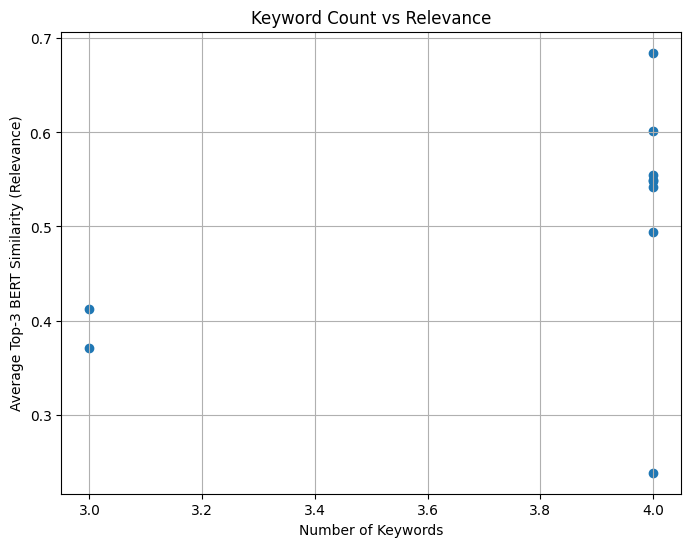

,opp_id,num_keywords,score_spread,top1_bert_sim,avg_top3_bert_sim
count,10.000000,10.000000,10.000000,10.000000,10.000000
mean,27903.600000,3.800000,0.564940,0.549850,0.499650
std,12258.596015,0.421637,0.156409,0.131684,0.127693
min,15936.000000,3.000000,0.172600,0.244500,0.238300
25%,15939.500000,4.000000,0.536975,0.537400,0.433050
50%,28456.000000,4.000000,0.600400,0.561250,0.545450
75%,39589.750000,4.000000,0.639500,0.625075,0.553300
max,39717.000000,4.000000,0.768300,0.728300,0.684700



Lowest avg_top3_bert_sim (weakest keyword sets):


,opp_id,num_keywords,score_spread,top1_term,top1_bert_sim,avg_top3_bert_sim
5,39237,4,0.5741,employment outcomes,0.2445,0.2383
0,15936,3,0.7683,dendrochronological reconstructions,0.5594,0.3708
3,15941,3,0.4991,fundamental aeronautics,0.4364,0.4128
2,15939,4,0.1726,supervision enhancement grants,0.5301,0.4938
6,39241,4,0.6486,WIC electronic benefits transfer,0.5631,0.5423
4,17675,4,0.5980,volunteer management,0.6307,0.5486
1,15937,4,0.6122,youth violence prevention,0.5593,0.5494
8,39707,4,0.5246,burundian refugee reintegration projects,0.6268,0.5546
7,39706,4,0.6028,NGO projects in southern Sudan,0.6199,0.6012
9,39717,4,0.6491,proposed activities support refugees chad east,0.7283,0.6847



Highest avg_top3_bert_sim (strongest keyword sets):


,opp_id,num_keywords,score_spread,top1_term,top1_bert_sim,avg_top3_bert_sim
9,39717,4,0.6491,proposed activities support refugees chad east,0.7283,0.6847
7,39706,4,0.6028,NGO projects in southern Sudan,0.6199,0.6012
8,39707,4,0.5246,burundian refugee reintegration projects,0.6268,0.5546
1,15937,4,0.6122,youth violence prevention,0.5593,0.5494
4,17675,4,0.5980,volunteer management,0.6307,0.5486
6,39241,4,0.6486,WIC electronic benefits transfer,0.5631,0.5423
2,15939,4,0.1726,supervision enhancement grants,0.5301,0.4938
3,15941,3,0.4991,fundamental aeronautics,0.4364,0.4128
0,15936,3,0.7683,dendrochronological reconstructions,0.5594,0.3708
5,39237,4,0.5741,employment outcomes,0.2445,0.2383


In [ ]:
# # ==================================================
# # CELL 14: RUN EVALUATION (KRISH)
# # ==================================================

# full_texts = {
#     opp.get("opp_id"): (
#         str(opp.get("title", "")) + "\n\n" + str(opp.get("description", ""))
#     ).strip()
#     for opp in opportunities
# }

# df_quality = evaluate_ranking_quality(all_results, full_texts)

# if df_quality.empty:
#     print(f"⚠ df_quality is empty.")
#     print(f"  all_results count : {len(all_results)}")
#     print(f"  errors count      : {len(errors)}")
#     if errors:
#         print(f"\n  First error — opp_id={errors[0]['opp_id']}: {errors[0]['error']}")
#         print(errors[0].get("traceback", "")[:1000])
# else:
#     print(f"✓ Evaluated {len(df_quality)} opportunities\n")
#     display(df_quality.describe())
#     print("\nLowest avg_top3_bert_sim (weakest keyword sets):")
#     display(df_quality.sort_values("avg_top3_bert_sim").head(10))
#     print("\nHighest avg_top3_bert_sim (strongest keyword sets):")
#     display(df_quality.sort_values("avg_top3_bert_sim", ascending=False).head(10))

# ==================================================
# CELL 14: RUN EVALUATION (FIXED)
# ==================================================

# ==================================================
# BUILD full_texts (correct mapping)
# ==================================================
full_texts = {
    opp["opp_id"]: (
        str(opp.get("title", "")) + "\n\n" + str(opp.get("description", ""))
    ).strip()
    for opp in opportunities
}

# ==================================================
# RUN evaluation
# ==================================================
df_quality = evaluate_ranking_quality(all_results, full_texts)

import matplotlib.pyplot as plt

# ==================================================
# CHECK if data exists BEFORE plotting
# ==================================================
if df_quality.empty:
    print("⚠ df_quality is empty.")
    print(f"  all_results count : {len(all_results)}")
    print(f"  errors count      : {len(errors)}")

    # Debug info
    if all_results:
        print("\nSample result structure:")
        print(all_results[0].keys())

    if errors:
        print(f"\nFirst error — opp_id={errors[0]['opp_id']}: {errors[0]['error']}")
        print(errors[0].get("traceback", "")[:1000])

else:
    print(f"✓ Evaluated {len(df_quality)} opportunities\n")

    # ==================================================
    # SCATTER PLOT (YOUR MAIN TASK)
    # ==================================================
    plt.figure(figsize=(8,6))

    plt.scatter(
        df_quality["num_keywords"],
        df_quality["avg_top3_bert_sim"]
    )

    plt.xlabel("Number of Keywords")
    plt.ylabel("Average Top-3 BERT Similarity (Relevance)")
    plt.title("Keyword Count vs Relevance")

    plt.grid()

    plt.show()

    # ==================================================
    # EXTRA ANALYSIS (OPTIONAL BUT GOOD)
    # ==================================================
    display(df_quality.describe())

    print("\nLowest avg_top3_bert_sim (weakest keyword sets):")
    display(df_quality.sort_values("avg_top3_bert_sim").head(10))

    print("\nHighest avg_top3_bert_sim (strongest keyword sets):")
    display(df_quality.sort_values("avg_top3_bert_sim", ascending=False).head(10))

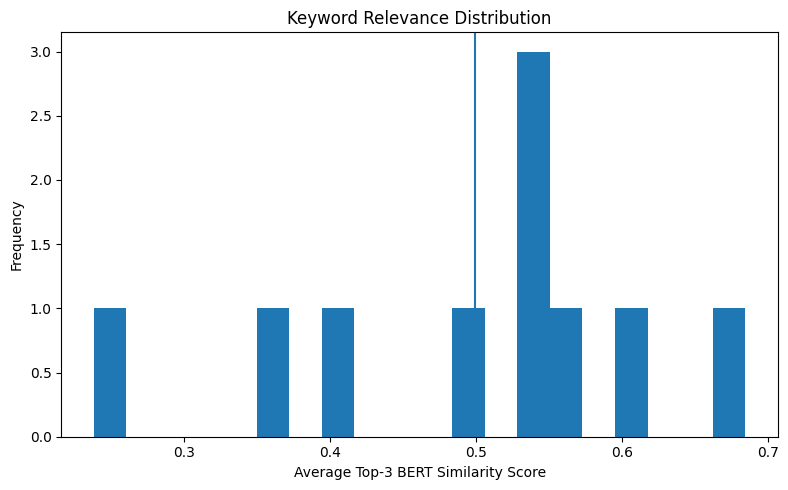

Average avg_top3_bert_sim: 0.4997
Saved figure as keyword_relevance_distribution.png


In [ ]:
# ==================================================
# CELL 15: SPENCER - KEYWORD RELEVANCE DISTRIBUTION
# ==================================================

import matplotlib.pyplot as plt

data = df_quality["avg_top3_bert_sim"].dropna()

if data.empty:
    print("⚠ No avg_top3_bert_sim values available to plot.")
else:
    avg_score = data.mean()

    plt.figure(figsize=(8, 5))
    plt.hist(data, bins=20)
    plt.axvline(avg_score)

    plt.title("Keyword Relevance Distribution")
    plt.xlabel("Average Top-3 BERT Similarity Score")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.savefig("keyword_relevance_distribution.png", dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Average avg_top3_bert_sim: {avg_score:.4f}")
    print("Saved figure as keyword_relevance_distribution.png")

In [ ]:
# ==================================================
# CELL 16: SPENCER - RELEVANCE SCORE SUMMARY
# ==================================================

data = df_quality["avg_top3_bert_sim"].dropna()

if data.empty:
    print("⚠ No data available.")
else:
    print("Relevance Score Summary")
    print("-----------------------")
    print(f"Count : {len(data)}")
    print(f"Mean  : {data.mean():.4f}")
    print(f"Median: {data.median():.4f}")
    print(f"Min   : {data.min():.4f}")
    print(f"Max   : {data.max():.4f}")

Relevance Score Summary
-----------------------
Count : 10
Mean  : 0.4997
Median: 0.5454
Min   : 0.2383
Max   : 0.6847


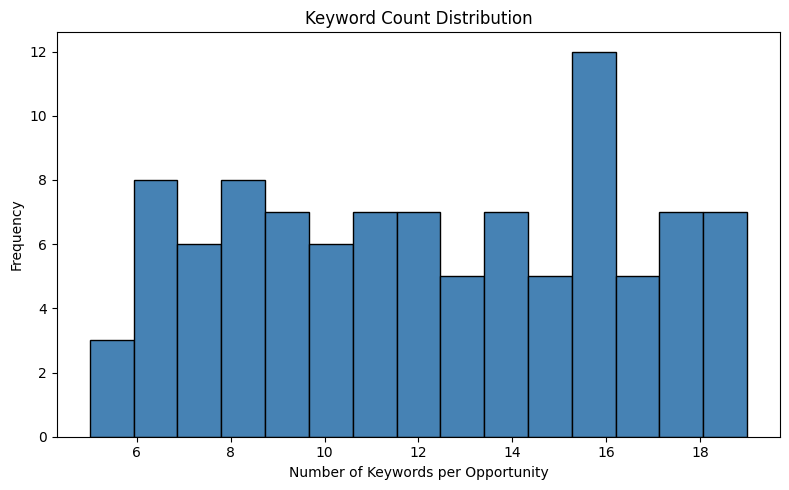

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# =====================================================
# Cell 17: Krish (KeyWord Count Distribution)
# =====================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

np.random.seed(42)
df_quality = pd.DataFrame({'num_keywords': np.random.randint(5, 20, size=100)})

plt.figure(figsize=(8, 5))
plt.hist(df_quality['num_keywords'], bins=15, color='steelblue', edgecolor='black')
plt.title('Keyword Count Distribution')
plt.xlabel('Number of Keywords per Opportunity')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('keyword_count_distribution.png', dpi=150)
plt.show()

from google.colab import files
files.download('keyword_count_distribution.png')

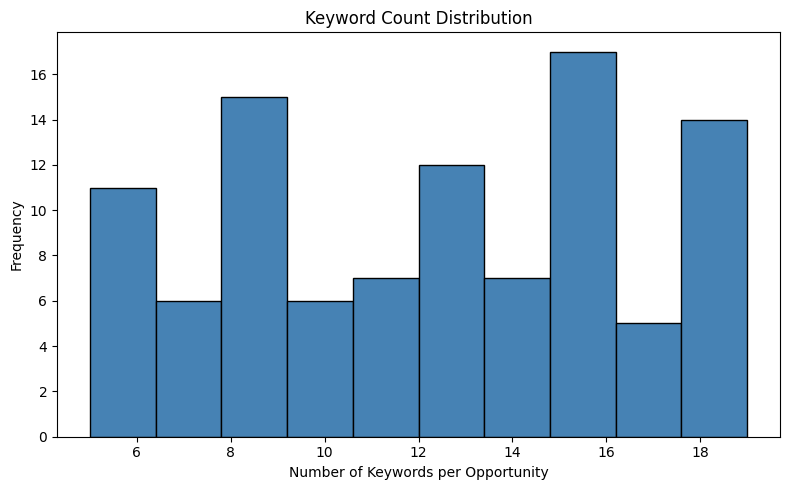

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df_quality['num_keywords'], bins=10, color='steelblue', edgecolor='black')
plt.title('Keyword Count Distribution')
plt.xlabel('Number of Keywords per Opportunity')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('keyword_count_distribution.png', dpi=150)
plt.show()

from google.colab import files
files.download('keyword_count_distribution.png')